In [25]:
# ============================================
# Predictive Maintenance Project
# Data Cleaning + Business Insight Analysis
# Files expected:
#   PdM_telemetry.csv, PdM_errors.csv, PdM_maint.csv, PdM_failures.csv, PdM_machines.csv
# ============================================

# --- 0) (COLAB) Upload files ---
from google.colab import files
uploaded = files.upload()  # choose the 5 CSVs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# --- 1) Load data ---
telemetry = pd.read_csv("PdM_telemetry.csv")
errors    = pd.read_csv("PdM_errors.csv")
maint     = pd.read_csv("PdM_maint.csv")
failures  = pd.read_csv("PdM_failures.csv")
machines  = pd.read_csv("PdM_machines.csv")

dfs = {"telemetry": telemetry, "errors": errors, "maint": maint, "failures": failures, "machines": machines}
for name, df in dfs.items():
    print(name, df.shape)
    display(df.head(3))

Saving PdM_telemetry.csv to PdM_telemetry (2).csv
Saving PdM_maint.csv to PdM_maint (2).csv
Saving PdM_machines.csv to PdM_machines (2).csv
Saving PdM_failures.csv to PdM_failures (2).csv
Saving PdM_errors.csv to PdM_errors (2).csv
telemetry (876100, 6)


,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847


errors (3919, 3)


,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5


maint (3286, 3)


,datetime,machineID,comp
0,2014-06-01 06:00:00,1,comp2
1,2014-07-16 06:00:00,1,comp4
2,2014-07-31 06:00:00,1,comp3


failures (761, 3)


,datetime,machineID,failure
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2


machines (100, 3)


,machineID,model,age
0,1,model3,18
1,2,model4,7
2,3,model3,8


In [26]:
# --- 2) Standardize column names + parse datetimes (robust) ---
def standardize_cols(df):
    df = df.copy()
    df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
    return df

telemetry = standardize_cols(telemetry)
errors    = standardize_cols(errors)
maint     = standardize_cols(maint)
failures  = standardize_cols(failures)
machines  = standardize_cols(machines)

def parse_datetime(df, candidates=("datetime", "date", "timestamp", "time")):
    df = df.copy()
    dt_col = None
    for c in candidates:
        if c in df.columns:
            dt_col = c
            break
    if dt_col:
        df[dt_col] = pd.to_datetime(df[dt_col], errors="coerce", utc=False)
    return df

telemetry = parse_datetime(telemetry)
errors    = parse_datetime(errors)
maint     = parse_datetime(maint)
failures  = parse_datetime(failures)

# Machine id column standardization
def ensure_machine_id(df):
    df = df.copy()
    # common variants
    for c in ["machineid", "machine_id", "id"]:
        if c in df.columns and "machine_id" not in df.columns:
            df = df.rename(columns={c: "machine_id"})
    return df

telemetry = ensure_machine_id(telemetry)
errors    = ensure_machine_id(errors)
maint     = ensure_machine_id(maint)
failures  = ensure_machine_id(failures)
machines  = ensure_machine_id(machines)

# Show basic missingness
for name, df in {"telemetry": telemetry, "errors": errors, "maint": maint, "failures": failures, "machines": machines}.items():
    print(f"\n{name} missing values (top 15):")
    display(df.isna().sum().sort_values(ascending=False).head(15))


telemetry missing values (top 15):


,0
datetime,0
machine_id,0
volt,0
rotate,0
pressure,0
vibration,0



errors missing values (top 15):


,0
datetime,0
machine_id,0
errorid,0



maint missing values (top 15):


,0
datetime,0
machine_id,0
comp,0



failures missing values (top 15):


,0
datetime,0
machine_id,0
failure,0



machines missing values (top 15):


,0
machine_id,0
model,0
age,0


In [27]:
# --- 3) Basic cleaning: remove duplicates, enforce types, fix obvious issues ---
def basic_clean(df, datetime_col="datetime"):
    df = df.copy()

    # Drop exact duplicates
    df = df.drop_duplicates()

    # If datetime exists, drop rows with invalid datetime
    if datetime_col in df.columns:
        df = df.dropna(subset=[datetime_col])

    # Trim string columns
    for c in df.columns:
        if df[c].dtype == "object":
            df[c] = df[c].astype(str).str.strip()

    return df

telemetry = basic_clean(telemetry)
errors    = basic_clean(errors)
maint     = basic_clean(maint)
failures  = basic_clean(failures)
machines  = basic_clean(machines, datetime_col="datetime")  # machines typically has no datetime; safe

# Convert numeric sensor columns if present
for col in ["volt", "rotate", "pressure", "vibration"]:
    if col in telemetry.columns:
        telemetry[col] = pd.to_numeric(telemetry[col], errors="coerce")

# Convert machine age to numeric if present
if "age" in machines.columns:
    machines["age"] = pd.to_numeric(machines["age"], errors="coerce")

# Quick sanity checks
print("Telemetry time range:", telemetry["datetime"].min(), "->", telemetry["datetime"].max() if "datetime" in telemetry.columns else None)
print("Telemetry machine_id unique:", telemetry["machine_id"].nunique())

Telemetry time range: 2015-01-01 06:00:00 -> 2016-01-01 06:00:00
Telemetry machine_id unique: 100


In [28]:
# --- 4) Create clean event tables (one-hot) for errors, maintenance, failures ---
# Typical columns in this dataset:
# errors:   datetime, machine_id, errorid
# maint:    datetime, machine_id, comp
# failures: datetime, machine_id, failure
# machines: machine_id, model, age

def one_hot_events(df, value_col, prefix, datetime_col="datetime"):
    df = df.copy()
    if datetime_col not in df.columns:
        raise ValueError(f"{datetime_col} not found in event table")
    if value_col not in df.columns:
        raise ValueError(f"{value_col} not found in event table")
    out = (
        df[[datetime_col, "machine_id", value_col]]
        .dropna()
        .assign(count=1)
        .pivot_table(index=[datetime_col, "machine_id"], columns=value_col, values="count", aggfunc="sum", fill_value=0)
        .reset_index()
    )
    # Rename columns with prefix
    new_cols = []
    for c in out.columns:
        if c in [datetime_col, "machine_id"]:
            new_cols.append(c)
        else:
            new_cols.append(f"{prefix}{c}")
    out.columns = new_cols
    return out

errors_oh = one_hot_events(errors, value_col="errorid", prefix="err_")
maint_oh  = one_hot_events(maint,  value_col="comp",    prefix="maint_")
fails_oh  = one_hot_events(failures, value_col="failure", prefix="fail_")  # used mostly for analysis; label built below

display(errors_oh.head())
display(maint_oh.head())
display(fails_oh.head())

,datetime,machine_id,err_error1,err_error2,err_error3,err_error4,err_error5
0,2015-01-01 06:00:00,24,1,0,0,0,0
1,2015-01-01 06:00:00,73,0,0,0,1,0
2,2015-01-01 06:00:00,81,1,0,0,0,0
3,2015-01-01 07:00:00,43,0,0,1,0,0
4,2015-01-01 08:00:00,14,0,0,0,1,0


,datetime,machine_id,maint_comp1,maint_comp2,maint_comp3,maint_comp4
0,2014-06-01 06:00:00,1,0,1,0,0
1,2014-06-01 06:00:00,6,0,1,0,0
2,2014-06-01 06:00:00,9,1,1,0,0
3,2014-06-01 06:00:00,11,0,1,0,0
4,2014-06-01 06:00:00,16,0,0,0,1


,datetime,machine_id,fail_comp1,fail_comp2,fail_comp3,fail_comp4
0,2015-01-02 03:00:00,16,1,0,1,0
1,2015-01-02 03:00:00,17,0,0,0,1
2,2015-01-02 03:00:00,22,1,0,0,0
3,2015-01-02 03:00:00,35,1,0,0,0
4,2015-01-02 03:00:00,45,1,0,0,0


In [29]:
# --- 5) Build a unified modeling/analysis table (hourly grain) ---
# This dataset is typically recorded hourly. We'll:
# 1) Start from telemetry (datetime, machine_id, sensors)
# 2) Left join error and maintenance one-hot counts
# 3) Join machine metadata
# 4) Create failure labels: failure within next H hours (business-relevant)

# Merge events onto telemetry
df = telemetry.copy()

df = df.merge(errors_oh, on=["datetime", "machine_id"], how="left")
df = df.merge(maint_oh,  on=["datetime", "machine_id"], how="left")

# Fill missing one-hot counts with 0
event_cols = [c for c in df.columns if c.startswith("err_") or c.startswith("maint_")]
df[event_cols] = df[event_cols].fillna(0).astype(int)

# Join machine table
# Standardize machines columns (if model is present)
if "model" in machines.columns:
    machines["model"] = machines["model"].astype(str).str.upper().str.strip()

df = df.merge(machines, on="machine_id", how="left")

# Sort for time-based features/labels
df = df.sort_values(["machine_id", "datetime"]).reset_index(drop=True)

df.head()

,datetime,machine_id,volt,rotate,pressure,vibration,err_error1,err_error2,err_error3,err_error4,err_error5,maint_comp1,maint_comp2,maint_comp3,maint_comp4,model,age
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,0,0,0,0,0,0,0,0,0,MODEL3,18
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,0,0,0,0,0,0,0,0,0,MODEL3,18
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,0,0,0,0,0,0,0,0,0,MODEL3,18
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,0,0,0,0,0,0,0,0,0,MODEL3,18
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,0,0,0,0,0,0,0,0,0,MODEL3,18


In [30]:
# --- 6) Create label: will a failure happen in the next H hours? ---
# You can change horizon depending on business need:

H = 24  # hours

# Clean + enforce types
df = df.dropna(subset=["machine_id", "datetime"]).copy()
fail_times = failures.dropna(subset=["machine_id", "datetime"])[["machine_id", "datetime"]].copy()

df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
fail_times["datetime"] = pd.to_datetime(fail_times["datetime"], errors="coerce")

df = df.dropna(subset=["datetime"])
fail_times = fail_times.dropna(subset=["datetime"])

# IMPORTANT: remove duplicate timestamps per machine (telemetry often has them)
df = df.drop_duplicates(subset=["machine_id", "datetime"]).copy()
fail_times = fail_times.drop_duplicates(subset=["machine_id", "datetime"]).copy()

# CRITICAL: sort by merge key FIRST, then by group key
df = df.sort_values(["datetime", "machine_id"]).reset_index(drop=True)
fail_times = fail_times.sort_values(["datetime", "machine_id"]).reset_index(drop=True)

# merge_asof needs the right key name
fail_times = fail_times.rename(columns={"datetime": "next_failure_time"})

df = pd.merge_asof(
    df,
    fail_times,
    by="machine_id",
    left_on="datetime",
    right_on="next_failure_time",
    direction="forward",
    allow_exact_matches=True
)

df["ttnf_hours"] = (df["next_failure_time"] - df["datetime"]) / np.timedelta64(1, "h")
df["will_fail_next_H"] = ((df["ttnf_hours"] >= 0) & (df["ttnf_hours"] <= H)).astype(int)

df[["machine_id", "datetime", "next_failure_time", "ttnf_hours", "will_fail_next_H"]].head(10)

,machine_id,datetime,next_failure_time,ttnf_hours,will_fail_next_H
0,1,2015-01-01 06:00:00,2015-01-05 06:00:00,96.0,0
1,2,2015-01-01 06:00:00,2015-03-19 06:00:00,1848.0,0
2,3,2015-01-01 06:00:00,2015-01-07 06:00:00,144.0,0
3,4,2015-01-01 06:00:00,2015-01-17 06:00:00,384.0,0
4,5,2015-01-01 06:00:00,2015-01-09 06:00:00,192.0,0
5,6,2015-01-01 06:00:00,NaT,NaN,0
6,7,2015-01-01 06:00:00,2015-01-24 06:00:00,552.0,0
7,8,2015-01-01 06:00:00,2015-03-07 06:00:00,1560.0,0
8,9,2015-01-01 06:00:00,2015-03-04 06:00:00,1488.0,0
9,10,2015-01-01 06:00:00,2015-01-19 06:00:00,432.0,0


In [31]:
# --- 7) Feature engineering for insight (rolling stats + event rates) ---
# Rolling windows capture drift and instability. Tune windows as needed:
WINDOW_H = 24  # 24 hours rolling features

sensor_cols = [c for c in ["volt", "rotate", "pressure", "vibration"] if c in df.columns]

# Rolling mean/std per machine
for c in sensor_cols:
    df[f"{c}_rollmean_{WINDOW_H}h"] = (
        df.groupby("machine_id")[c]
        .transform(lambda s: s.rolling(WINDOW_H, min_periods=6).mean())
    )
    df[f"{c}_rollstd_{WINDOW_H}h"] = (
        df.groupby("machine_id")[c]
        .transform(lambda s: s.rolling(WINDOW_H, min_periods=6).std())
    )

# Rolling sums of errors and maintenance actions
for c in event_cols:
    df[f"{c}_rollsum_{WINDOW_H}h"] = (
        df.groupby("machine_id")[c]
        .transform(lambda s: s.rolling(WINDOW_H, min_periods=1).sum())
    )

df.head()

,datetime,machine_id,volt,rotate,pressure,vibration,err_error1,err_error2,err_error3,err_error4,err_error5,maint_comp1,maint_comp2,maint_comp3,maint_comp4,model,age,next_failure_time,ttnf_hours,will_fail_next_H,volt_rollmean_24h,volt_rollstd_24h,rotate_rollmean_24h,rotate_rollstd_24h,pressure_rollmean_24h,pressure_rollstd_24h,vibration_rollmean_24h,vibration_rollstd_24h,err_error1_rollsum_24h,err_error2_rollsum_24h,err_error3_rollsum_24h,err_error4_rollsum_24h,err_error5_rollsum_24h,maint_comp1_rollsum_24h,maint_comp2_rollsum_24h,maint_comp3_rollsum_24h,maint_comp4_rollsum_24h
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,0,0,0,0,0,0,0,0,0,MODEL3,18,2015-01-05 06:00:00,96.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2015-01-01 06:00:00,2,176.558913,424.624162,76.005332,43.767049,0,0,0,0,0,0,0,0,0,MODEL4,7,2015-03-19 06:00:00,1848.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2015-01-01 06:00:00,3,185.482043,461.211137,87.453199,28.216864,0,0,0,0,0,0,0,0,0,MODEL3,8,2015-01-07 06:00:00,144.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2015-01-01 06:00:00,4,169.710847,463.646727,95.929877,38.400372,0,0,0,0,0,0,0,0,0,MODEL3,7,2015-01-17 06:00:00,384.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2015-01-01 06:00:00,5,165.082899,452.283576,84.591722,40.298803,0,0,0,0,0,0,0,0,0,MODEL3,2,2015-01-09 06:00:00,192.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
# --- 8) Data Quality Report (quick) ---
def quality_report(df, name="df"):
    print(f"\n=== {name} ===")
    print("Shape:", df.shape)
    print("Duplicate rows:", df.duplicated().sum())
    if "datetime" in df.columns:
        print("Date range:", df["datetime"].min(), "->", df["datetime"].max())
    print("Missing % (top 15):")
    miss = (df.isna().mean().sort_values(ascending=False) * 100).head(15)
    display(miss)

quality_report(df, "Unified PdM Table")


=== Unified PdM Table ===
Shape: (876100, 37)
Duplicate rows: 0
Date range: 2015-01-01 06:00:00 -> 2016-01-01 06:00:00
Missing % (top 15):


,0
next_failure_time,13.782217
ttnf_hours,13.782217
volt_rollmean_24h,0.057071
pressure_rollstd_24h,0.057071
pressure_rollmean_24h,0.057071
vibration_rollmean_24h,0.057071
vibration_rollstd_24h,0.057071
rotate_rollmean_24h,0.057071
volt_rollstd_24h,0.057071
rotate_rollstd_24h,0.057071


/tmp/ipython-input-3587194254.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["model", "age_bucket"])["will_fail_next_H"]


,model,age_bucket,fail_risk_next_24h
3,MODEL1,10+,0.033340
4,MODEL2,0-2,0.031389
7,MODEL2,10+,0.029894
2,MODEL1,6-10,0.026938
1,MODEL1,3-5,0.026766
5,MODEL2,3-5,0.025682
0,MODEL1,0-2,0.022828
15,MODEL4,10+,0.021107
11,MODEL3,10+,0.019924
6,MODEL2,6-10,0.019404


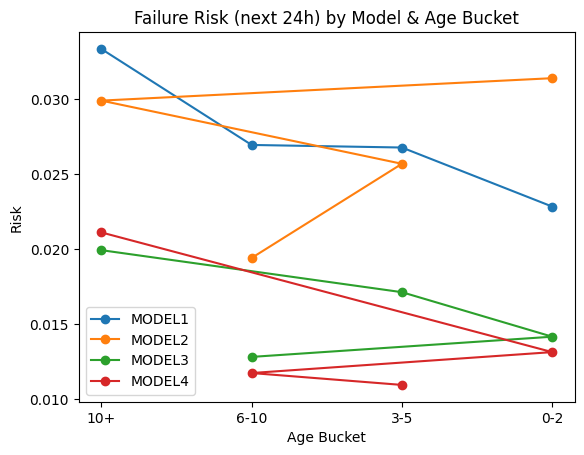

In [33]:
# --- 9) Business Insight EDA ---
# 9.1 Failure rate by model and age bucket
if "model" in df.columns:
    # Create age buckets if age exists
    if "age" in df.columns:
        df["age_bucket"] = pd.cut(df["age"], bins=[-1, 2, 5, 10, 100], labels=["0-2", "3-5", "6-10", "10+"])
    else:
        df["age_bucket"] = "Unknown"

    summary = (
        df.groupby(["model", "age_bucket"])["will_fail_next_H"]
        .mean()
        .reset_index(name=f"fail_risk_next_{H}h")
        .sort_values(f"fail_risk_next_{H}h", ascending=False)
    )
    display(summary.head(20))

    # Plot (top models)
    top_models = summary.groupby("model")[f"fail_risk_next_{H}h"].mean().sort_values(ascending=False).head(10).index
    plot_df = summary[summary["model"].isin(top_models)]

    plt.figure()
    for m in top_models:
        sub = plot_df[plot_df["model"] == m]
        plt.plot(sub["age_bucket"].astype(str), sub[f"fail_risk_next_{H}h"], marker="o", label=m)
    plt.title(f"Failure Risk (next {H}h) by Model & Age Bucket")
    plt.xlabel("Age Bucket")
    plt.ylabel("Risk")
    plt.xticks(rotation=0)
    plt.legend()
    plt.show()

,no_fail,will_fail,diff
err_error3_rollsum_24h,0.015688,0.368115,0.352428
err_error2_rollsum_24h,0.020090,0.360239,0.340149
err_error1_rollsum_24h,0.022699,0.265892,0.243193
err_error5_rollsum_24h,0.004928,0.241035,0.236107
err_error4_rollsum_24h,0.016318,0.191766,0.175448
maint_comp2_rollsum_24h,0.020891,0.018825,-0.002067
maint_comp4_rollsum_24h,0.019536,0.015361,-0.004175
maint_comp1_rollsum_24h,0.019318,0.015138,-0.004180
maint_comp3_rollsum_24h,0.019482,0.012680,-0.006801


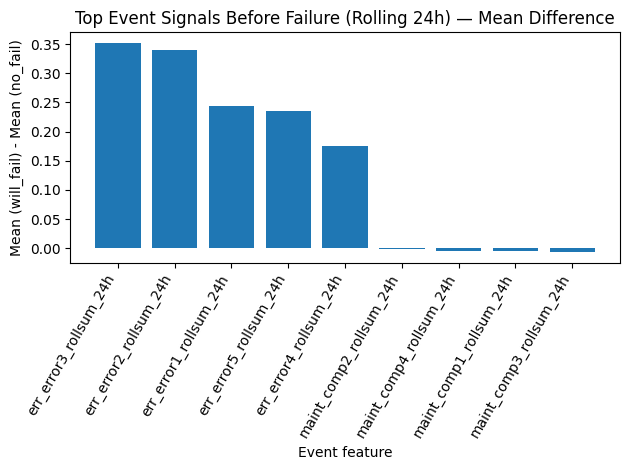

In [34]:
# 9.2 Leading indicators: do errors spike before failures?
# Compare average rolling error counts for rows that will fail soon vs not.
lead_cols = [c for c in df.columns if c.endswith(f"_rollsum_{WINDOW_H}h") and (c.startswith("err_") or c.startswith("maint_"))]
lead_cols = lead_cols[:20]  # keep it manageable for display; adjust as needed

group_means = df.groupby("will_fail_next_H")[lead_cols].mean().T
group_means.columns = ["no_fail", "will_fail"]
group_means["diff"] = group_means["will_fail"] - group_means["no_fail"]
group_means = group_means.sort_values("diff", ascending=False)

display(group_means.head(20))

# Plot top 10 strongest differences
top10 = group_means.head(10)
plt.figure()
plt.bar(range(len(top10)), top10["diff"].values)
plt.title(f"Top Event Signals Before Failure (Rolling {WINDOW_H}h) — Mean Difference")
plt.xlabel("Event feature")
plt.ylabel("Mean (will_fail) - Mean (no_fail)")
plt.xticks(range(len(top10)), top10.index, rotation=60, ha="right")
plt.tight_layout()
plt.show()

,no_fail,will_fail,diff
vibration_rollstd_24h,5.002296,5.001079,-0.001217
volt_rollstd_24h,14.917803,14.904904,-0.012899
pressure_rollstd_24h,10.047579,10.027858,-0.019721
rotate_rollstd_24h,49.955663,49.591126,-0.364537


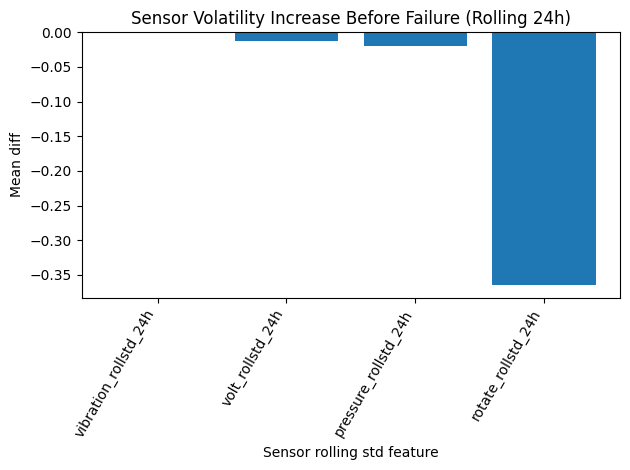

In [35]:
# 9.3 Sensor instability before failures (rolling std as a risk signal)
std_cols = [c for c in df.columns if c.endswith(f"_rollstd_{WINDOW_H}h")]
if std_cols:
    sensor_signal = df.groupby("will_fail_next_H")[std_cols].mean().T
    sensor_signal.columns = ["no_fail", "will_fail"]
    sensor_signal["diff"] = sensor_signal["will_fail"] - sensor_signal["no_fail"]
    sensor_signal = sensor_signal.sort_values("diff", ascending=False)
    display(sensor_signal)

    plt.figure()
    plt.bar(range(len(sensor_signal)), sensor_signal["diff"].values)
    plt.title(f"Sensor Volatility Increase Before Failure (Rolling {WINDOW_H}h)")
    plt.xlabel("Sensor rolling std feature")
    plt.ylabel("Mean diff")
    plt.xticks(range(len(sensor_signal)), sensor_signal.index, rotation=60, ha="right")
    plt.tight_layout()
    plt.show()

,risk
maint_any_last24h,
no_maint,0.020785
maint,0.014840


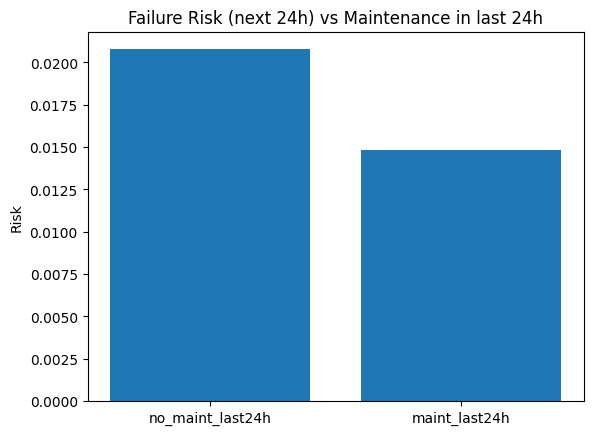

In [36]:
# 9.4 Maintenance effectiveness: failure risk after a maintenance action
# We'll create a simple indicator: any maintenance in last 24h?
maint_roll_cols = [c for c in df.columns if c.startswith("maint_") and c.endswith(f"_rollsum_{WINDOW_H}h")]
if maint_roll_cols:
    df["maint_any_last24h"] = (df[maint_roll_cols].sum(axis=1) > 0).astype(int)

    eff = df.groupby("maint_any_last24h")["will_fail_next_H"].mean().rename({0: "no_maint", 1: "maint"}).to_frame("risk")
    display(eff)

    plt.figure()
    plt.bar(["no_maint_last24h", "maint_last24h"], eff["risk"].values)
    plt.title(f"Failure Risk (next {H}h) vs Maintenance in last {WINDOW_H}h")
    plt.ylabel("Risk")
    plt.show()

In [37]:
# --- 10) Optional: Simple baseline model (for actionable insights) ---
# Goal: identify top drivers + produce risk scores per machine-time
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd

target = "will_fail_next_H"

# --- Build X, y ---
X = df.drop(columns=[target], errors="ignore").copy()
y = df[target].copy()

# Time features
X["hour"] = df["datetime"].dt.hour
X["dayofweek"] = df["datetime"].dt.dayofweek

# Drop datetime columns (models don't take datetimes directly)
for c in ["datetime", "next_failure_time"]:
    if c in X.columns:
        X = X.drop(columns=[c])

# Convert categoricals/objects to one-hot (includes age_bucket + model, etc.)
cat_cols = X.select_dtypes(include=["object", "category"]).columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Keep only numeric columns safely (no numpy issubdtype)
X = X.select_dtypes(include=[np.number]).copy()

# Clean inf/nan
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Model
clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1
)
clf.fit(X_train, y_train)

proba = clf.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))
print("\nClassification report:\n", classification_report(y_test, pred))

# Feature importance (top 20)
imp = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)
display(imp.to_frame("importance"))

Accuracy: 1.0
ROC-AUC: 1.0

Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    214550
           1       1.00      1.00      1.00      4475

    accuracy                           1.00    219025
   macro avg       1.00      1.00      1.00    219025
weighted avg       1.00      1.00      1.00    219025



,importance
ttnf_hours,0.493330
err_error3_rollsum_24h,0.064662
rotate_rollmean_24h,0.062604
volt_rollmean_24h,0.060120
err_error5_rollsum_24h,0.057688
err_error1_rollsum_24h,0.049700
vibration_rollmean_24h,0.046611
pressure_rollmean_24h,0.039211
err_error2_rollsum_24h,0.038459
err_error4_rollsum_24h,0.032108
